[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/14_busqueda_informada/notebooks/01_grafos_ponderados.ipynb)

# Notebook 01: Grafos Ponderados y Colas de Prioridad

En el módulo 13 aprendimos a representar grafos y a buscar caminos con BFS, DFS e IDDFS.
Todos esos algoritmos asumen que **moverse de un nodo a otro tiene el mismo costo**.

En la realidad, las aristas tienen **pesos**: una ruta entre ciudades puede tener 50 km
o 200 km, y queremos encontrar el camino de **menor costo total**, no el de menor número
de saltos.

En este notebook construimos los cimientos de la búsqueda informada:

1. **Representar grafos ponderados** como diccionarios de adyacencia con pesos
2. **Entender por qué BFS falla** en grafos con pesos distintos
3. **Dominar la cola de prioridad** (`heapq`) como estructura fundamental
4. **Implementar `PriorityFrontier`**, la frontera que usarán Dijkstra y A*

> **Prerequisito:** haber leído `01_grafos_ponderados_y_prioridad.md` en las notas del curso.

In [1]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib networkx


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import heapq
from collections import defaultdict

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "primary":   "#2563EB",
    "secondary": "#10B981",
    "accent":    "#F59E0B",
    "danger":    "#EF4444",
    "node":      "#93C5FD",
    "edge":      "#475569",
}

print("Dependencias cargadas correctamente.")


Dependencias cargadas correctamente.


---
## Sección 1: Grafos Ponderados

Un **grafo ponderado** asigna un número real a cada arista: $w : E \to \mathbb{R}$.
En problemas de ruta, $w(u, v)$ suele ser la distancia o el tiempo de viaje.

La representación más cómoda en Python es un **diccionario de adyacencia con pesos**:

```python
grafo = {
    'A': [('B', 5), ('C', 2)],   # A → B con peso 5, A → C con peso 2
    'B': [('D', 4)],
    ...
}
```

Cada vecino se convierte en una tupla `(nodo_destino, peso)`. El resto del código
de búsqueda solo necesita saber cómo extraer esas tuplas.

### Costo de un camino

Dado un camino $p = v_0, v_1, \ldots, v_k$, su **costo total** es:

$$g(p) = \sum_{i=0}^{k-1} w(v_i, v_{i+1})$$

Queremos encontrar el camino $p^*$ de mínimo costo entre el nodo inicial y la meta.

In [3]:
# Grafo ponderado: red de ciudades (8 nodos, ~13 aristas)
# Los pesos representan distancias en kilómetros
ciudades = {
    'Monterrey':  [('Saltillo', 87),  ('Linares', 130), ('Nuevo Laredo', 230)],
    'Saltillo':   [('Monterrey', 87), ('Zacatecas', 310), ('Torreón', 270)],
    'Linares':    [('Monterrey', 130), ('Tampico', 310)],
    'Nuevo Laredo': [('Monterrey', 230), ('Saltillo', 295)],
    'Torreón':    [('Saltillo', 270), ('Zacatecas', 315), ('Durango', 245)],
    'Zacatecas':  [('Saltillo', 310), ('Torreón', 315), ('Aguascalientes', 125)],
    'Durango':    [('Torreón', 245), ('Aguascalientes', 320)],
    'Aguascalientes': [('Zacatecas', 125), ('Durango', 320)],
    'Tampico':    [('Linares', 310)],
}

print("Grafo de ciudades cargado.")
print(f"Nodos: {list(ciudades.keys())}")
total_aristas = sum(len(v) for v in ciudades.values()) // 2
print(f"Aristas (aprox.): {total_aristas}")


Grafo de ciudades cargado.
Nodos: ['Monterrey', 'Saltillo', 'Linares', 'Nuevo Laredo', 'Torreón', 'Zacatecas', 'Durango', 'Aguascalientes', 'Tampico']
Aristas (aprox.): 10


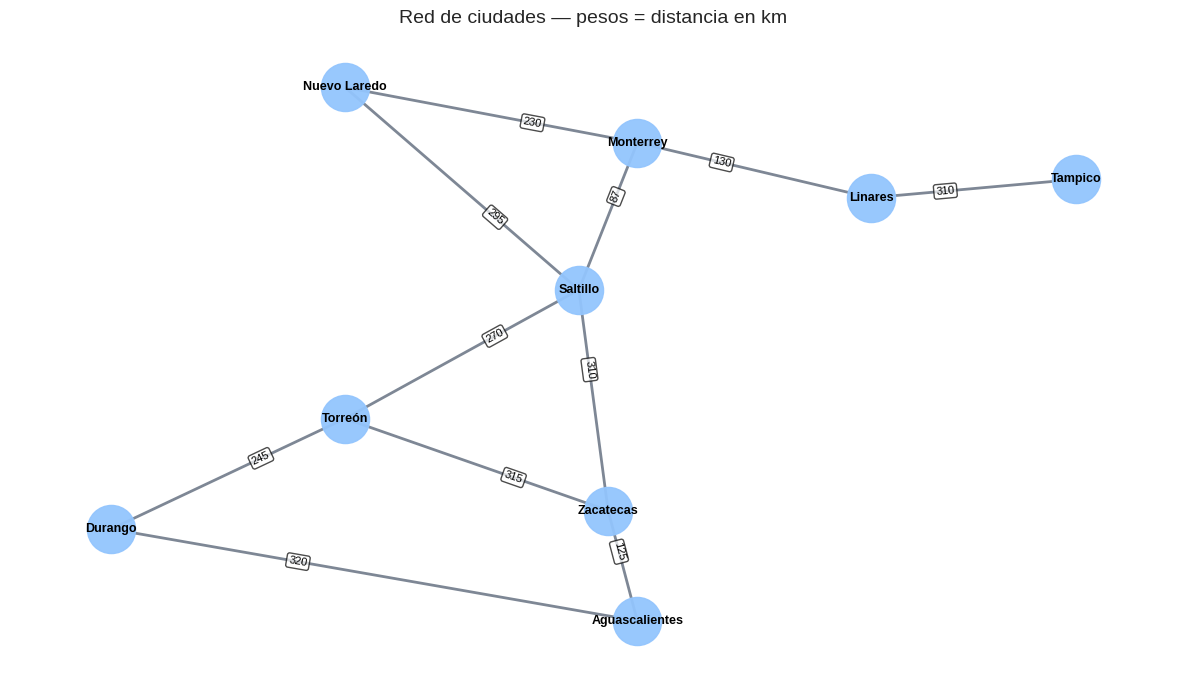

In [4]:
# Visualización con NetworkX
G = nx.Graph()
for origen, destinos in ciudades.items():
    for destino, peso in destinos:
        G.add_edge(origen, destino, weight=peso)

# Posiciones manuales aproximadas (longitud, latitud invertida)
pos = {
    'Nuevo Laredo':    (0.0,  1.0),
    'Monterrey':       (1.0,  0.7),
    'Tampico':         (2.5,  0.5),
    'Linares':         (1.8,  0.4),
    'Saltillo':        (0.8, -0.1),
    'Torreón':         (0.0, -0.8),
    'Durango':         (-0.8, -1.4),
    'Zacatecas':       (0.9, -1.3),
    'Aguascalientes':  (1.0, -1.9),
}

edge_labels = nx.get_edge_attributes(G, 'weight')

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=COLORS["node"],
                       node_size=1200, alpha=0.95)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=COLORS["edge"],
                       width=2, alpha=0.7)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              ax=ax, font_size=8,
                              label_pos=0.35,
                              bbox=dict(boxstyle='round,pad=0.2',
                                        fc='white', alpha=0.7))
ax.set_title("Red de ciudades — pesos = distancia en km", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## Sección 2: ¿Por qué Falla BFS?

BFS garantiza el camino con **menor número de aristas**. Pero cuando las aristas tienen
pesos distintos, el camino con menos saltos **no** es necesariamente el de menor costo.

### Contraejemplo

Considera el siguiente grafo de 5 nodos:

```
S --1-- A --1-- G
|               ^
10              |
|               |
B ------8------- C
```

- BFS encuentra `S → A → G` (2 saltos, costo = **2**) ✓
- Pero ¿qué pasa si el grafo es así?

```
S --10-- A --10-- G
|                 ^
1                 |
|                 |
B -------1------- C
```

- BFS sigue devolviendo `S → A → G` (2 saltos, costo = **20**)
- El camino óptimo es `S → B → C → G` (3 saltos, costo = **3**)

BFS **no puede ver los pesos**: para él, todos los saltos cuestan igual.

In [5]:
from collections import deque

# Contraejemplo: BFS falla con pesos heterogéneos
# S → A → G : 2 saltos, costo 20
# S → B → C → G : 3 saltos, costo 3
grafo_contra = {
    'S': [('A', 10), ('B', 1)],
    'A': [('S', 10), ('G', 10)],
    'B': [('S', 1),  ('C', 1)],
    'C': [('B', 1),  ('G', 1)],
    'G': [('A', 10), ('C', 1)],
}

def bfs_sin_pesos(grafo, inicio, meta):
    """BFS clásico: ignora los pesos, solo cuenta saltos."""
    cola = deque([(inicio, [inicio])])
    visitados = {inicio}
    while cola:
        nodo, camino = cola.popleft()
        if nodo == meta:
            return camino
        for vecino, _ in grafo[nodo]:   # ignoramos el peso '_'
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append((vecino, camino + [vecino]))
    return None

def costo_camino(grafo, camino):
    """Calcula el costo total de un camino en un grafo ponderado."""
    costo = 0
    for i in range(len(camino) - 1):
        u, v = camino[i], camino[i+1]
        for vecino, peso in grafo[u]:
            if vecino == v:
                costo += peso
                break
    return costo

camino_bfs = bfs_sin_pesos(grafo_contra, 'S', 'G')
camino_optimo = ['S', 'B', 'C', 'G']

print("=== BFS en grafo ponderado ===")
print(f"BFS devuelve:        {' → '.join(camino_bfs)}")
print(f"  Número de saltos:  {len(camino_bfs) - 1}")
print(f"  Costo total:       {costo_camino(grafo_contra, camino_bfs)}")
print()
print(f"Camino óptimo:       {' → '.join(camino_optimo)}")
print(f"  Número de saltos:  {len(camino_optimo) - 1}")
print(f"  Costo total:       {costo_camino(grafo_contra, camino_optimo)}")
print()
print("→ BFS eligió el camino de MENOS saltos, pero NO el de menor costo.")
print("  Necesitamos una frontera que ordene por costo acumulado, no por saltos.")


=== BFS en grafo ponderado ===
BFS devuelve:        S → A → G
  Número de saltos:  2
  Costo total:       20

Camino óptimo:       S → B → C → G
  Número de saltos:  3
  Costo total:       3

→ BFS eligió el camino de MENOS saltos, pero NO el de menor costo.
  Necesitamos una frontera que ordene por costo acumulado, no por saltos.


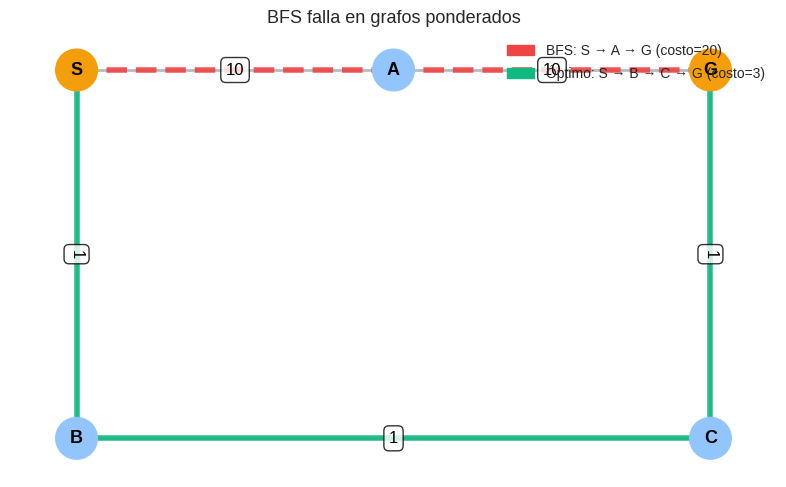

In [6]:
# Visualizar el contraejemplo
G_contra = nx.Graph()
for u, vecinos in grafo_contra.items():
    for v, w in vecinos:
        G_contra.add_edge(u, v, weight=w)

pos_contra = {'S': (0, 1), 'A': (1, 1), 'G': (2, 1),
              'B': (0, 0), 'C': (2, 0)}
edge_labels_contra = nx.get_edge_attributes(G_contra, 'weight')

# Identificar aristas de cada camino
aristas_bfs = list(zip(camino_bfs, camino_bfs[1:]))
aristas_opt = list(zip(camino_optimo, camino_optimo[1:]))

fig, ax = plt.subplots(figsize=(8, 5))

# Aristas base
nx.draw_networkx_edges(G_contra, pos_contra, ax=ax,
                       edge_color=COLORS["edge"], width=2, alpha=0.4)

# Camino BFS (rojo)
nx.draw_networkx_edges(G_contra, pos_contra,
                       edgelist=aristas_bfs, ax=ax,
                       edge_color=COLORS["danger"], width=4, alpha=0.9,
                       style='dashed')

# Camino óptimo (verde)
nx.draw_networkx_edges(G_contra, pos_contra,
                       edgelist=aristas_opt, ax=ax,
                       edge_color=COLORS["secondary"], width=4, alpha=0.9)

# Nodos
node_colors = [COLORS["accent"] if n in ('S', 'G') else COLORS["node"]
               for n in G_contra.nodes()]
nx.draw_networkx_nodes(G_contra, pos_contra, ax=ax,
                       node_color=node_colors, node_size=900)
nx.draw_networkx_labels(G_contra, pos_contra, ax=ax,
                        font_size=13, font_weight='bold')
nx.draw_networkx_edge_labels(G_contra, pos_contra,
                              edge_labels=edge_labels_contra,
                              ax=ax, font_size=12,
                              bbox=dict(boxstyle='round', fc='white', alpha=0.8))

parches = [
    mpatches.Patch(color=COLORS["danger"],    label=f'BFS: {" → ".join(camino_bfs)} (costo={costo_camino(grafo_contra, camino_bfs)})'),
    mpatches.Patch(color=COLORS["secondary"], label=f'Óptimo: {" → ".join(camino_optimo)} (costo={costo_camino(grafo_contra, camino_optimo)})'),
]
ax.legend(handles=parches, loc='upper right', fontsize=10)
ax.set_title("BFS falla en grafos ponderados", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## Sección 3: Cola de Prioridad con `heapq`

Para encontrar el camino de menor costo necesitamos siempre expandir el nodo con
**menor costo acumulado** desde el inicio. La estructura ideal es un **min-heap**.

### Min-heap

Un min-heap es un árbol binario parcialmente ordenado donde el **elemento mínimo
siempre está en la raíz**. Las operaciones clave son:

| Operación | Costo |
|-----------|-------|
| `heappush(h, x)` — insertar | $O(\log n)$ |
| `heappop(h)` — extraer mínimo | $O(\log n)$ |
| `h[0]` — ver mínimo sin extraer | $O(1)$ |

Python incluye `heapq` en la biblioteca estándar. Trabaja sobre listas normales de Python.

In [7]:
import heapq

# Demo básico de heapq
h = []
heapq.heappush(h, (5, 'tarea_baja'))
heapq.heappush(h, (1, 'urgente'))
heapq.heappush(h, (3, 'media'))
heapq.heappush(h, (2, 'importante'))

print("Extrayendo en orden de prioridad (menor primero):")
while h:
    prioridad, tarea = heapq.heappop(h)
    print(f"  prioridad={prioridad}  →  {tarea}")

print()
# heapq ordena por el primer elemento de la tupla
# Si hay empate en el primer elemento, desempata con el segundo
h2 = []
heapq.heappush(h2, (3, 'c', 'C'))
heapq.heappush(h2, (3, 'a', 'A'))
heapq.heappush(h2, (3, 'b', 'B'))
print("Con empate en prioridad, desempata por segundo elemento:")
while h2:
    p, key, val = heapq.heappop(h2)
    print(f"  ({p}, '{key}')  →  {val}")


Extrayendo en orden de prioridad (menor primero):
  prioridad=1  →  urgente
  prioridad=2  →  importante
  prioridad=3  →  media
  prioridad=5  →  tarea_baja

Con empate en prioridad, desempata por segundo elemento:
  (3, 'a')  →  A
  (3, 'b')  →  B
  (3, 'c')  →  C


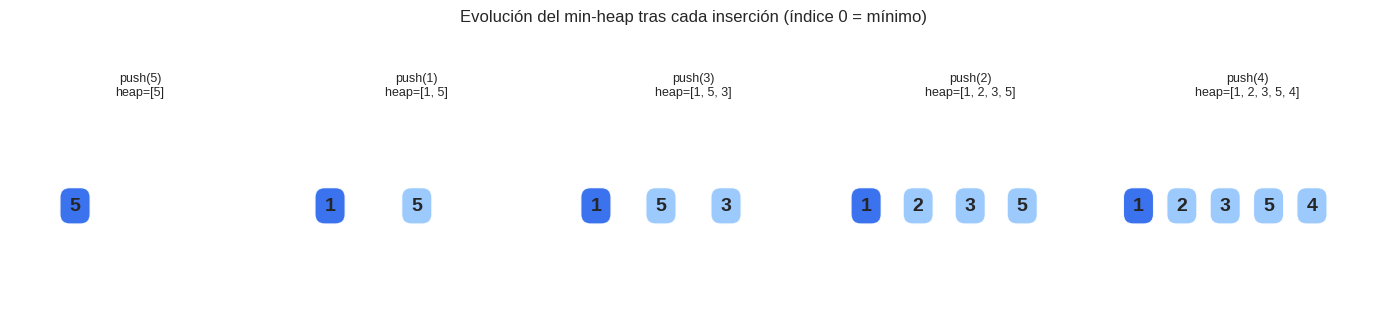

Mínimo actual (siempre en h[0]): 1


In [8]:
# Visualizar el proceso de inserción en el heap
elementos = [5, 1, 3, 2, 4]
h_demo = []
estados = []

for x in elementos:
    heapq.heappush(h_demo, x)
    estados.append(list(h_demo))

fig, axes = plt.subplots(1, len(elementos), figsize=(14, 3))
for i, (estado, ax) in enumerate(zip(estados, axes)):
    ax.barh([0], [1], color='white')  # fondo invisible
    ax.set_xlim(-0.5, max(len(estado), 1) + 0.5)
    ax.set_ylim(-1, 1)
    for j, val in enumerate(estado):
        color = COLORS["primary"] if j == 0 else COLORS["node"]
        ax.text(j, 0, str(val), ha='center', va='center',
                fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', fc=color,
                          ec='white', alpha=0.9))
    ax.set_title(f"push({elementos[i]})\nheap={estado}", fontsize=9)
    ax.axis('off')

plt.suptitle("Evolución del min-heap tras cada inserción (índice 0 = mínimo)",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print("Mínimo actual (siempre en h[0]):", h_demo[0])


In [9]:
class PriorityFrontier:
    """
    Frontera de prioridad para búsqueda informada.

    Mantiene los nodos ordenados por su costo (menor costo = mayor prioridad).
    Soporta la operación 'push_or_update': si un nodo ya está en la frontera
    pero encontramos un camino más barato, actualizamos su prioridad.

    Implementación:
    - min-heap de tuplas (costo, contador_de_insercion, nodo)
    - diccionario 'mejor' para consultar el mejor costo conocido de cada nodo
    - los nodos 'desactualizados' se descartan en el pop (lazy deletion)
    """

    def __init__(self):
        self._heap = []          # min-heap de (costo, contador, nodo)
        self._mejor = {}         # nodo → mejor costo conocido en la frontera
        self._contador = 0       # desempata cuando los costos son iguales

    def push(self, nodo, costo):
        """Inserta nodo con el costo dado. No verifica si ya existe."""
        heapq.heappush(self._heap, (costo, self._contador, nodo))
        self._mejor[nodo] = costo
        self._contador += 1

    def push_or_update(self, nodo, costo):
        """
        Inserta nodo si no existe. Si ya existe y el nuevo costo es menor,
        actualiza (inserta una nueva entrada; la vieja se ignora en pop).
        Devuelve True si se realizó la inserción/actualización.
        """
        if nodo not in self._mejor or costo < self._mejor[nodo]:
            self.push(nodo, costo)
            return True
        return False

    def pop(self):
        """
        Extrae el nodo con menor costo.
        Descarta entradas obsoletas (lazy deletion).
        Devuelve (nodo, costo).
        """
        while self._heap:
            costo, _, nodo = heapq.heappop(self._heap)
            # Verificar que esta entrada no está desactualizada
            if nodo in self._mejor and self._mejor[nodo] == costo:
                del self._mejor[nodo]
                return nodo, costo
        raise IndexError("pop de frontera vacía")

    def contains(self, nodo):
        """True si el nodo está actualmente en la frontera."""
        return nodo in self._mejor

    def is_empty(self):
        """True si la frontera no tiene nodos válidos."""
        return len(self._mejor) == 0

    def best_cost(self, nodo):
        """Devuelve el mejor costo conocido para nodo (o inf si no está)."""
        return self._mejor.get(nodo, float('inf'))


print("PriorityFrontier definida.")

# Test básico
pf = PriorityFrontier()
pf.push_or_update('A', 10)
pf.push_or_update('B', 3)
pf.push_or_update('C', 7)
pf.push_or_update('A', 2)   # actualización: A pasa de costo 10 a 2

print("Extrayendo en orden de costo:")
while not pf.is_empty():
    nodo, costo = pf.pop()
    print(f"  nodo={nodo}, costo={costo}")

assert True, "Test PriorityFrontier pasado"
print("\n✓ PriorityFrontier funciona correctamente.")


PriorityFrontier definida.
Extrayendo en orden de costo:
  nodo=A, costo=2
  nodo=B, costo=3
  nodo=C, costo=7

✓ PriorityFrontier funciona correctamente.


In [10]:
# Demostración: push_or_update en acción
# Simulamos el proceso de Dijkstra de forma manual en un grafo pequeño

grafo_demo = {
    'S': [('A', 4), ('B', 1)],
    'A': [('G', 3)],
    'B': [('A', 2), ('G', 8)],
    'G': [],
}

# Trazar manualmente las operaciones de la frontera
print("Traza manual de PriorityFrontier para el grafo demo:")
print("  S → A (costo 4)  y  S → B (costo 1)")
print()

pf2 = PriorityFrontier()
pf2.push_or_update('S', 0)

paso = 0
while not pf2.is_empty():
    nodo, costo = pf2.pop()
    paso += 1
    print(f"Paso {paso}: expansión de '{nodo}' con costo acumulado {costo}")
    for vecino, peso in grafo_demo.get(nodo, []):
        nuevo_costo = costo + peso
        actualizado = pf2.push_or_update(vecino, nuevo_costo)
        if actualizado:
            print(f"  → insertar/actualizar '{vecino}' con costo {nuevo_costo}")
        else:
            print(f"  → '{vecino}' ya tiene costo {pf2.best_cost(vecino)} ≤ {nuevo_costo}, ignorar")


Traza manual de PriorityFrontier para el grafo demo:
  S → A (costo 4)  y  S → B (costo 1)

Paso 1: expansión de 'S' con costo acumulado 0
  → insertar/actualizar 'A' con costo 4
  → insertar/actualizar 'B' con costo 1
Paso 2: expansión de 'B' con costo acumulado 1
  → insertar/actualizar 'A' con costo 3
  → insertar/actualizar 'G' con costo 9
Paso 3: expansión de 'A' con costo acumulado 3
  → insertar/actualizar 'G' con costo 6
Paso 4: expansión de 'G' con costo acumulado 6


---
## Ejercicio 1

Crea un grafo de transporte con al menos 8 nodos y pesos que representen
**tiempo de viaje en minutos**. Puede ser una red de metro, rutas de autobús,
o cualquier sistema de transporte urbano que conozcas.

Visualízalo con NetworkX mostrando los pesos en las aristas.

**Requisitos:**
- Al menos 8 nodos
- Al menos 10 aristas
- Pesos que representen minutos (valores razonables: 2–45 min)
- Visualización con `networkx` mostrando etiquetas de peso

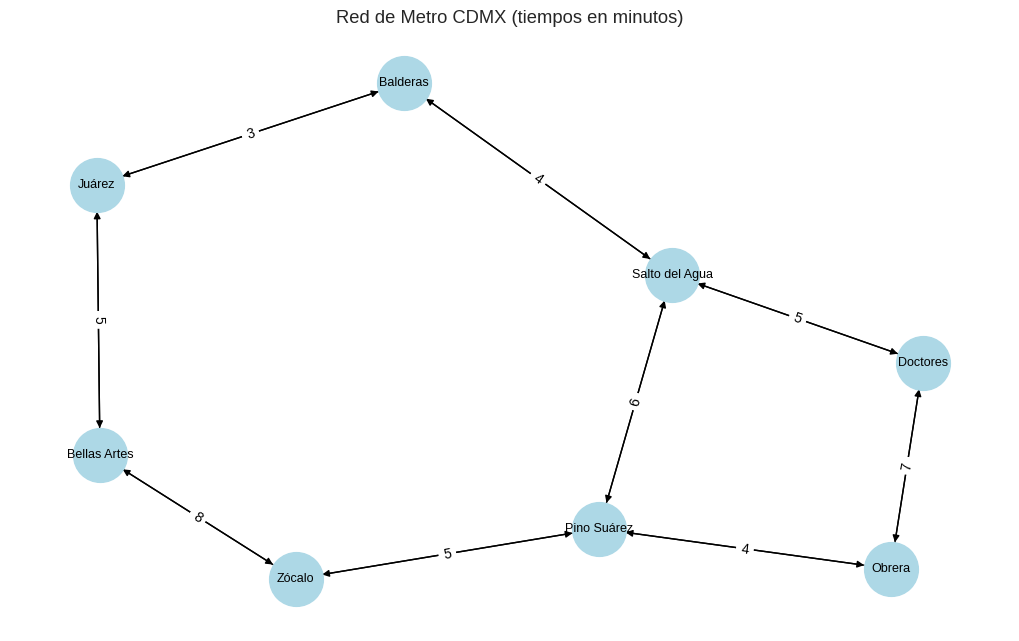

✓ Verificaciones pasadas


In [12]:
# Tu código aquí
import networkx as nx
import matplotlib.pyplot as plt

grafo_transporte = {
    'Balderas':     [('Salto del Agua', 4), ('Juárez', 3)],
    'Salto del Agua': [('Balderas', 4), ('Doctores', 5), ('Pino Suárez', 6)],
    'Juárez':       [('Balderas', 3), ('Bellas Artes', 5)],
    'Doctores':     [('Salto del Agua', 5), ('Obrera', 7)],
    'Pino Suárez':  [('Salto del Agua', 6), ('Obrera', 4), ('Zócalo', 5)],
    'Bellas Artes': [('Juárez', 5), ('Zócalo', 8)],
    'Obrera':       [('Doctores', 7), ('Pino Suárez', 4)],
    'Zócalo':       [('Pino Suárez', 5), ('Bellas Artes', 8)],
}

G = nx.DiGraph()
for nodo, vecinos in grafo_transporte.items():
    for dest, peso in vecinos:
        G.add_edge(nodo, dest, weight=peso)

pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=9)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Red de Metro CDMX (tiempos en minutos)")
plt.show()

assert len(grafo_transporte) >= 8
total_aristas_ej = sum(len(v) for v in grafo_transporte.values())
assert total_aristas_ej >= 10
for nodo, vecinos in grafo_transporte.items():
    for dest, peso in vecinos:
        assert peso > 0
print("✓ Verificaciones pasadas")

---
## Ejercicio 2

Implementa la función `dijkstra_all(grafo, inicio)` que devuelva el **diccionario
de distancias mínimas** desde `inicio` a todos los nodos alcanzables.

Usa tu `PriorityFrontier` implementada en la Sección 3.

**Firma esperada:**
```python
def dijkstra_all(grafo, inicio) -> dict:
    """
    Devuelve {nodo: distancia_minima} para todos los nodos
    alcanzables desde 'inicio' en el grafo ponderado.
    """
```

**Pista:** El algoritmo es idéntico a Dijkstra estándar, pero en lugar de detenerse
en la meta, continúa hasta que la frontera esté vacía.

In [16]:
def dijkstra_all(grafo, inicio):
    import heapq
    distancias = {inicio: 0}
    heap = [(0, inicio)]

    while heap:
        costo, nodo = heapq.heappop(heap)
        if costo > distancias.get(nodo, float('inf')):
            continue
        for vecino, peso in grafo.get(nodo, []):
            nuevo_costo = costo + peso
            if nuevo_costo < distancias.get(vecino, float('inf')):
                distancias[vecino] = nuevo_costo
                heapq.heappush(heap, (nuevo_costo, vecino))

    return distancias

In [17]:
dist = dijkstra_all(grafo_test, 'S')
print("Distancias desde S:", dist)
assert dist.get('S', None) == 0
assert dist.get('B', None) == 1
assert dist.get('A', None) == 3
assert dist.get('G', None) == 6
print("✓ Todos los tests pasaron")

Distancias desde S: {'S': 0, 'A': 3, 'B': 1, 'G': 6}
✓ Todos los tests pasaron
